<a href="https://colab.research.google.com/github/hooveranna/symmetry_for_ML/blob/master/vib_modes_6_S966_S25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab for 6.S966 Spring 2025 `vib_modes` exercises.
Import symm4ml and other libraries.

In [1]:
%%capture
!rm symm4ml_obfuscated.zip
!wget -O symm4ml_obfuscated.zip https://symm4ml.mit.edu/_static/symm4ml_s25/symm4ml/symm4ml_obfuscated_20250222.zip
!unzip -o symm4ml_obfuscated.zip
import sys
sys.path.append('/content/symm4ml_obfuscated')

In [2]:
%%capture
!pip install pymatgen

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import symm4ml
from symm4ml import groups, groups_fast, linalg, rep, vib_modes, vis

## We'll be using `pymatgen` to get some common PointGroups.
`pymatgen` uses the [Hermann–Mauguin notation](https://en.wikipedia.org/wiki/Hermann%E2%80%93Mauguin_notation) whereas in class, we've been primarily using [Schoenflies notation](https://en.wikipedia.org/wiki/Schoenflies_notation), so we included a dictionary in `symm4ml.vib_modes` that has a dictionary to convert between then. Read more about [Crystallographic Point Groups here.](https://en.wikipedia.org/wiki/Crystallographic_point_group)

In [ ]:
vib_modes.point_group_dict.keys()

dict_keys(['C1', 'Ci', 'C2', 'Cs', 'C2h', 'D2', 'C2v', 'D2h', 'C4', 'S4', 'C4h', 'D4', 'C4v', 'D2d', 'D4h', 'C3', 'S6', 'D3', 'C3v', 'D3d', 'C6', 'C3h', 'C6h', 'D6', 'C6v', 'D3h', 'D6h', 'T', 'Th', 'O', 'Td', 'Oh'])

In [ ]:
# Weird hack to fix a circular import ¯\_(ツ)_/¯
try:
  from pymatgen.symmetry.groups import PointGroup
except:
  from pymatgen.symmetry.groups import PointGroup

## We'll primarily use the tetrahedral group $T_d$ and it's subgroup $C_{2v}$, but we also have some questions in the homework for the octahedral group $O_h$.

In [ ]:
# Define the tetrahedral point group: Schoenflies notation (Td) and Hermmann-Mauguin notation (-43m)
Td_group = PointGroup(vib_modes.point_group_dict['Td'])
# Extract the rotation components from each SymmOp in the symmetry operations
Td = np.stack([op.rotation_matrix for op in Td_group.symmetry_ops], axis=0)
Td_vec = Td
Td.shape
Td_table = groups.make_multiplication_table(Td)
np.random.seed(42)
Td_irreps = rep.infer_irreps(Td_table)

In [ ]:
# Define the tetrahedral point group: Schoenflies notation (Td) and Hermmann-Mauguin notation (-43m)
C2v_group = PointGroup(vib_modes.point_group_dict['C2v'])
# Extract the rotation components from each SymmOp in the symmetry operations
C2v = np.stack([op.rotation_matrix for op in C2v_group.symmetry_ops], axis=0)
C2v_vec = C2v
C2v.shape
C2v_table = groups.make_multiplication_table(C2v)
np.random.seed(42)
C2v_irreps = rep.infer_irreps(C2v_table)

### This take a while to run -- you can uncomment and run if you wish

In [ ]:
# # Define the tetrahedral point group: Schoenflies notation (Td) and Hermmann-Mauguin notation (-43m)
# Oh_group = PointGroup(vib_modes.point_group_dict['Oh'])
# # Extract the rotation components from each SymmOp in the symmetry operations
# Oh = np.stack([op.rotation_matrix for op in Oh_group.symmetry_ops], axis=0)
# Oh_vec = Oh
# Oh.shape
# Oh_table = groups.make_multiplication_table(Oh)
# np.random.seed(42)
# Oh_irreps = rep.infer_irreps(Oh_table)

## Build tetrahedron and representations of tetrahedral group in terms of permutation on vertices

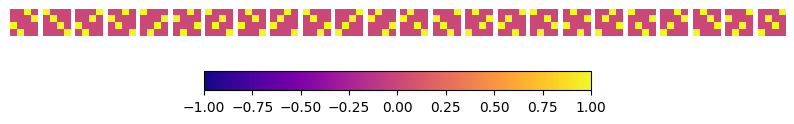

In [ ]:
tet = np.unique(np.einsum('nij,j->ni', Td, np.array([1, 1, 1])), axis=0)

Td_perm = vib_modes.permutation_representation(tet, Td_vec, eps=1e-3)
vis.plot_matrices(Td_perm, figsize=(10,3));

## Build translation and rotation projectors (subspaces)

In [ ]:
proj_trans = vib_modes.translation_projector(4)
proj_rot = vib_modes.rotation_projector(tet)
print('Translation projector rank: ', np.linalg.matrix_rank(proj_trans), "Shape: ", proj_trans.shape)
print('Rotation projector rank: ', np.linalg.matrix_rank(proj_rot), "Shape: ", proj_rot.shape)

Translation projector rank:  3 Shape:  (12, 12)
Rotation projector rank:  3 Shape:  (12, 12)


## Plot projection matrix for vibrational degrees of freedom (subspace of $3n$ dimensions)
Total d.o.f. = $3 \times n$ d.o.f. - $3$ rot - $3$ trans

Rank of Vibration Projector:  6
Should be 3(4) - 6 = 6.


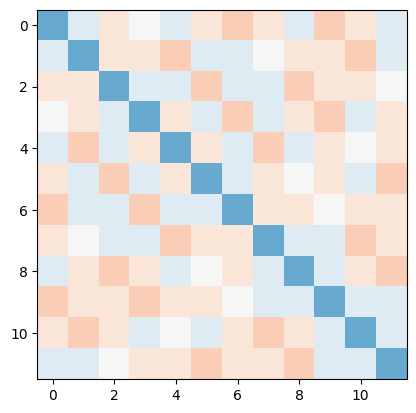

In [ ]:
vib_proj = vib_modes.vibration_projector(tet)
print("Rank of Vibration Projector: ", np.linalg.matrix_rank(vib_proj))
print("Should be 3({}) - 6 = {}.".format(len(tet), 3 * len(tet) - 6))
plt.imshow(vib_proj, vmax=1, vmin=-1, cmap='RdBu');

# Build representation of group on vibration subspace
1. Build tensor product representation of $\Gamma_{perm} \otimes \Gamma_{vec}$
2. Build vibration projector.
3. Use vibration projector to project tensor product representation to vibration subspace.
4. Get orthogonal bases that spans each irrep subspace.

In [ ]:
tp_rep = rep.tensor_product(Td_perm, Td_vec)

## Get new subspace of tetrahedron vibration modes by projecting `tp_rep` onto `vib_proj`
Each matrix of representation should have rank $3n - 6$

In [ ]:
tp_rep_sub_proj = np.einsum('ij,kl,njl->nik', vib_proj, vib_proj, tp_rep)
print(tp_rep_sub_proj.shape)

(24, 12, 12)


In [ ]:
np.linalg.matrix_rank(tp_rep_sub_proj)

array([6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6])

# We've already reordered the irreps and conjugacy classes to match the point group tables at (http://symmetry.jacobs-university.de/).

## We recommend trying it out yourself though to make sure you understand how we arrived at these re-orderings.

## Compare $T_d$ irreps and classes to standard table and reorder

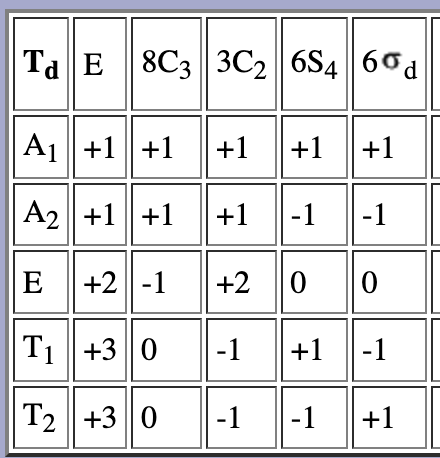

In [ ]:
Td_conj = groups.conjugacy_classes(Td_table)
Td_char_table = rep.character_table(Td_irreps, Td_conj).round(3).real
print(vib_modes.conjugacy_class_in_table_notation(Td_vec, Td_conj))
print(Td_char_table)

['sigma_?', 'E', 'C?_3', 'C?_2', 'S?_4']
[[ 1.  1.  1.  1.  1.]
 [-0.  2. -1.  2. -0.]
 [-1.  1.  1.  1. -1.]
 [ 1.  3.  0. -1. -1.]
 [-1.  3.  0. -1.  1.]]


In [ ]:
Td_conj_reordered = [list(Td_conj)[i] for i in [1, 2, 3, 4, 0]]
Td_irreps_reordered = [Td_irreps[i] for i in [0, 2, 1, 4, 3]]
Td_char_table_reordered = rep.character_table(Td_irreps_reordered, Td_conj_reordered).round(3).real

Td_conj_reordered_labels = [r'E', r'C_3', r'C_2', r'S_4', r'\sigma_d']
Td_irreps_reordered_labels = ['A_1', 'A_2', 'E', 'T_1', 'T_2']

print(vib_modes.conjugacy_class_in_table_notation(Td_vec, Td_conj_reordered))
print(Td_conj_reordered_labels)
print(Td_char_table_reordered)

['E', 'C?_3', 'C?_2', 'S?_4', 'sigma_?']
['E', 'C_3', 'C_2', 'S_4', '\\sigma_d']
[[ 1.  1.  1.  1.  1.]
 [ 1.  1.  1. -1. -1.]
 [ 2. -1.  2. -0. -0.]
 [ 3.  0. -1.  1. -1.]
 [ 3.  0. -1. -1.  1.]]


## Compare $C_{2v}$ irreps and classes to standard table and reorder

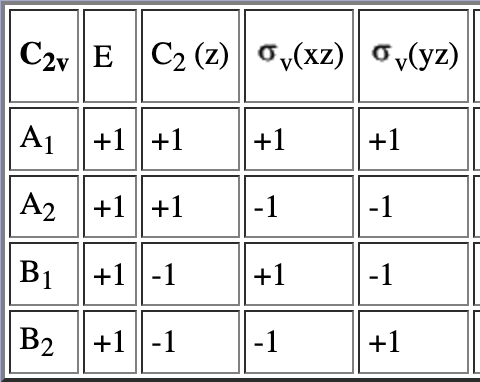

In [ ]:
C2v_conj = groups.conjugacy_classes(C2v_table)
C2v_char_table = rep.character_table(C2v_irreps, C2v_conj).round(3).real
print(vib_modes.conjugacy_class_in_table_notation(C2v_vec, C2v_conj))
print(C2v_char_table)

['C?_2', 'E', 'sigma_?', 'sigma_?']
[[-1.  1.  1. -1.]
 [-1.  1. -1.  1.]
 [ 1.  1. -1. -1.]
 [ 1.  1.  1.  1.]]


In [ ]:
print(C2v_conj)
print(C2v_vec[[1, 0]]) # The 0 element is \sigma_{yz}, note the -1 in the xx index

{frozenset({3}), frozenset({2}), frozenset({1}), frozenset({0})}
[[[ 1.  0.  0.]
  [ 0. -1.  0.]
  [ 0.  0.  1.]]

 [[-1.  0.  0.]
  [ 0.  1.  0.]
  [ 0.  0.  1.]]]


In [ ]:
C2v_conj_order = [1, 0, 2, 3]
C2v_conj_reordered = [list(C2v_conj)[i] for i in C2v_conj_order]
C2v_irreps_reordered = [C2v_irreps[i] for i in [3, 2, 0, 1]]
C2v_char_table_reordered = rep.character_table(C2v_irreps_reordered, C2v_conj_reordered).round(3).real

C2v_conj_reordered_labels = [r'E', r'C_2', r'\sigma_{xz}', r'\sigma_{yz}']
C2v_irreps_reordered_labels = ['A_1', 'A_2', 'B_1', 'B_2']

print(vib_modes.conjugacy_class_in_table_notation(C2v_vec, C2v_conj_reordered))
print(C2v_conj_reordered_labels)
print(C2v_char_table_reordered)

['E', 'C?_2', 'sigma_?', 'sigma_?']
['E', 'C_2', '\\sigma_{xz}', '\\sigma_{yz}']
[[ 1.  1.  1.  1.]
 [ 1.  1. -1. -1.]
 [ 1. -1.  1. -1.]
 [ 1. -1. -1.  1.]]


## Compare $O_h$ irreps and classes to standard table and reorder

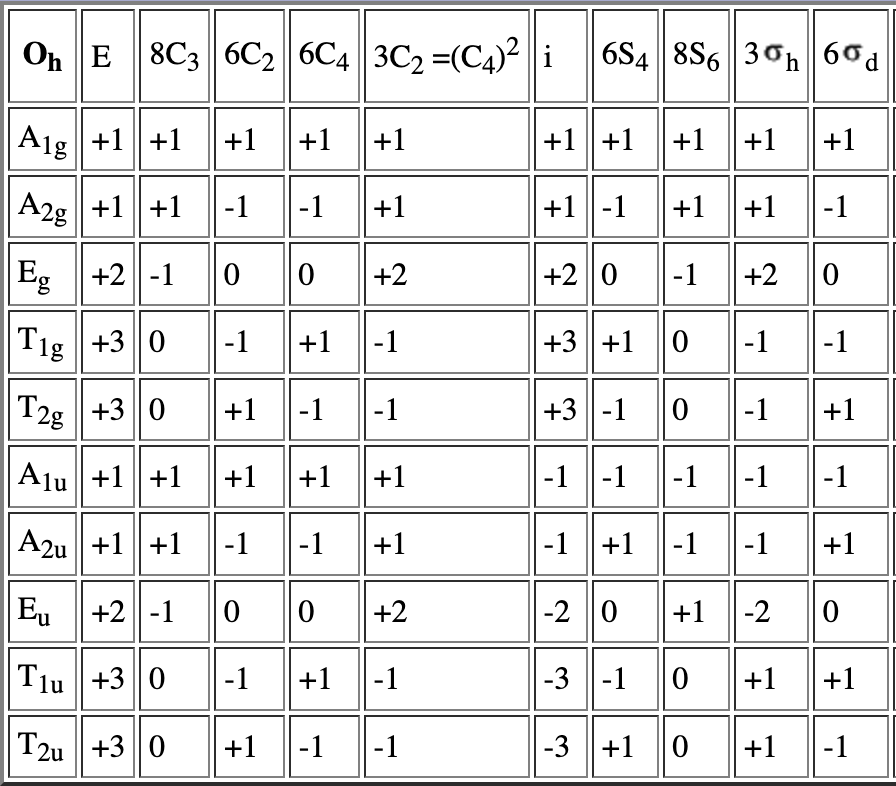

It helps to also print out the size of each class because overlapping classes have different elements. For some reason, we get $S_3$ for the class that should be $S_6$ according to the table -- haven't figured out why. If you look at the vector representations of these elements, they do look like $S_3$ operations.

### Also commenting out this because it takes a while to run -- you can uncomment

In [ ]:
# Oh_conj = groups.conjugacy_classes(Oh_table)
# Oh_char_table = rep.character_table(Oh_irreps, Oh_conj).round(3).real
# print(vib_modes.conjugacy_class_in_table_notation(Oh_vec, Oh_conj))
# print([len(c) for c in Oh_conj])
# print(Oh_char_table)

In [ ]:
# Oh_conj_reordered = [list(Oh_conj)[i] for i in [3, 5, -1, 4, 1, -3, 0, -2, 2, -4]]
# Oh_irreps_reordered = Oh_irreps
# Oh_irreps_reordered = [Oh_irreps[i] for i in [0, 1, -3, -1, 4, 3, 2, 5, -2, -4]]
# Oh_char_table_reordered = rep.character_table(Oh_irreps_reordered, Oh_conj_reordered).round(3).real

# Oh_conj_reordered_labels = [r'E', r'8C_3', r'6C_2', r'6C_4', r'3C_2=(C_4)^2', r'i', r'6S_4', r'8S_6', r'3\sigma_{h}', r'6\sigma_{d}']
# Oh_irreps_reordered_labels = ['A_{1g}', 'A_{2g}', 'E_g', 'T_{1g}', 'T_{2g}', 'A_{1u}', 'A_{2u}', 'E_g', 'T_{1u}', 'T_{2u}']

# print(vib_modes.conjugacy_class_in_table_notation(Oh_vec, Oh_conj_reordered))
# print(Oh_conj_reordered_labels)
# print(Oh_char_table_reordered)

## Vibration irrep projectors
Using projectors helps us ensure that (if it is possible), we are mapping to the reals (rather than complex numbers). If the projector for a given irrep is zero, then this is equivalent to saying that the irrep

['A_1', 'A_2', 'E', 'T_1', 'T_2']
Irrep projector ranks:  [1, 0, 2, 0, 3]


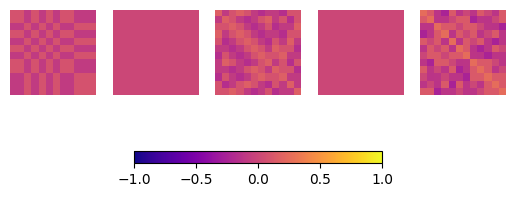

In [ ]:
tet_vib_irrep_proj = vib_modes.vibration_irrep_projectors(tet, Td_vec, Td_irreps_reordered)
vis.plot_matrices(tet_vib_irrep_proj);
print(Td_irreps_reordered_labels)
print("Irrep projector ranks: ", [np.linalg.matrix_rank(p) for p in tet_vib_irrep_proj])

['A_{1g}', 'A_{2g}', 'E_g', 'T_{1g}', 'T_{2g}', 'A_{1u}', 'A_{2u}', 'E_g', 'T_{1u}', 'T_{2u}']
Irrep projector ranks:  [1, 0, 2, 0, 3, 0, 0, 0, 3, 3]


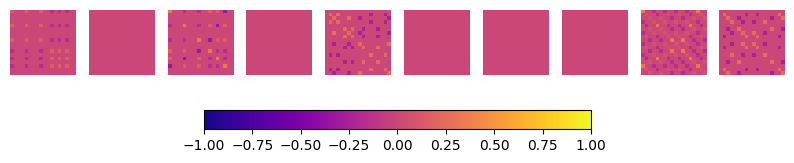

In [ ]:
oct_vib_irrep_proj = vib_modes.vibration_irrep_projectors(vib_modes.octahedron, Oh_vec, Oh_irreps_reordered)
vis.plot_matrices(oct_vib_irrep_proj, figsize=(10, 3));
print(Oh_irreps_reordered_labels)
print("Irrep projector ranks: ", [np.linalg.matrix_rank(p) for p in oct_vib_irrep_proj])

## Vibrational modes of tetrahedron and octahedron by irrep

### Tetrahedron

In [ ]:
Td_vib_modes = vib_modes.vibrational_modes(tet, Td_vec, Td_irreps_reordered)
for l, m in zip(Td_irreps_reordered_labels, Td_vib_modes):
  print("\t".join([l+":", str(m.shape)]))

A_1:	(1, 12)
A_2:	(0, 12)
E:	(2, 12)
T_1:	(0, 12)
T_2:	(3, 12)


### Octahedron

In [ ]:
# Oh_vib_modes = vib_modes.vibrational_modes(vib_modes.octahedron, Oh_vec, Oh_irreps_reordered)
# for l, m in zip(Oh_irreps_reordered_labels, Oh_vib_modes):
#   print("\t".join([l+":", str(m.shape)]))

# Plot modes
http://gernot-katzers-spice-pages.com/character_tables/Td.html

## Trivial / Scalar ($A_1$) Mode

In [ ]:
vib_modes.plot_vibrational_mode(tet, Td_vib_modes[0].reshape(4, 3))

## 2D $E$ mode

In [ ]:
vib_modes.plot_vibrational_mode(tet, Td_vib_modes[2][0].reshape(4, 3))

In [ ]:
vib_modes.plot_vibrational_mode(tet, Td_vib_modes[2][1].reshape(4, 3))

In [ ]:
U, S, Vt = np.linalg.svd(Td_vib_modes[2])

In [ ]:
np.allclose(linalg.projector_vec(Td_vib_modes[2], sum=True), linalg.projector_vec(Vt[:2], sum=True), atol=1e-6)

True

In [ ]:
vib_modes.plot_vibrational_mode(tet, Vt[0].reshape(4, 3))

In [ ]:
vib_modes.plot_vibrational_mode(tet, Vt[1].reshape(4, 3))

## 3D $T$ mode

In [ ]:
vib_modes.plot_vibrational_mode(tet, Td_vib_modes[4][0].reshape(4, 3))
# vib_modes.plot_vibrational_mode(tet, Td_vib_modes[4][1].reshape(4, 3))
# vib_modes.plot_vibrational_mode(tet, Td_vib_modes[4][2].reshape(4, 3))

In [ ]:
U, S, Vt = np.linalg.svd(Td_vib_modes[4])
np.allclose(linalg.projector_vec(Td_vib_modes[4], sum=True), linalg.projector_vec(Vt[:3], sum=True), atol=1e-6)

True

In [ ]:
vib_modes.plot_vibrational_mode(tet, Vt[0].reshape(4, 3))

In [ ]:
vib_modes.plot_vibrational_mode(tet, Vt[1].reshape(4, 3))

In [ ]:
vib_modes.plot_vibrational_mode(tet, Vt[2].reshape(4, 3))

# Now we are going to use what we've learned above to learn how to distort higher symmetry shape into a specific subgroup.

# Find subgroups of $T_d$ that are isomorphic to $C_{2v}$

In [ ]:
Td_sub_iso_C2v = vib_modes.isomorphic_subgroups(Td_table, C2v_table)
print(set(frozenset(i) for i,j in vib_modes.isomorphic_subgroups(Td_table, C2v_table)))
print(sorted([len(j) for i, j in vib_modes.isomorphic_subgroups(Td_table, C2v_table)]))

{frozenset({1, 11, 12, 9}), frozenset({0, 1, 10, 11}), frozenset({0, 1, 4, 8}), frozenset({1, 10, 6, 23})}
[6, 6, 6, 6]


# Looking at the pattern we see that even though these are also isomorphic -- only 3 of the 4 actually "do" the same thing.
* The group of {0, 1, 10, 11} is a different thing. It contains the identity and all C_2 axes.
* The other groups contain the identity, two mirrors and a C_2 axis

In [ ]:
print(Td_conj_reordered_labels)
print(Td_conj_reordered)

['E', 'C_3', 'C_2', 'S_4', '\\sigma_d']
[frozenset({1}), frozenset({3, 7, 14, 15, 16, 18, 19, 22}), frozenset({0, 10, 11}), frozenset({2, 5, 13, 17, 20, 21}), frozenset({4, 6, 8, 9, 12, 23})]


# The irreps of a group are typically reducible under a subgroup. How do the irreps of $T_d$ break up (reduce) under the subgroup $C_{2v}$?

In [ ]:
sub = 1
print(list(Td_sub_iso_C2v[sub][0]), [Td_sub_iso_C2v[sub][1]])

# Choosing one of the elements
sub_reordered_elements = [Td_sub_iso_C2v[sub][0][i] for i in Td_sub_iso_C2v[sub][1][0]]
print(sub_reordered_elements)
branch_Td_C2v = vib_modes.branching_change_of_basis(Td_irreps_reordered, C2v_irreps_reordered, sub_reordered_elements)

[1, 10, 6, 23] [[array([1, 2, 0, 3], dtype=int32), array([1, 3, 0, 2], dtype=int32), array([2, 1, 0, 3], dtype=int32), array([3, 1, 0, 2], dtype=int32), array([2, 3, 0, 1], dtype=int32), array([3, 2, 0, 1], dtype=int32)]]
[10, 6, 1, 23]


In [ ]:
print('\t' + '\t\t'.join(C2v_irreps_reordered_labels))
for i, s_g in enumerate(Td_irreps_reordered_labels):
    print(Td_irreps_reordered_labels[i], "\t", "\t".join([str(branch_Td_C2v[i][j].shape) for j, s_h in enumerate(C2v_irreps_reordered_labels)]))

	A_1		A_2		B_1		B_2
A_1 	 (1, 1, 1)	(0, 1, 1)	(0, 1, 1)	(0, 1, 1)
A_2 	 (0, 1, 1)	(0, 1, 1)	(0, 1, 1)	(1, 1, 1)
E 	 (1, 1, 2)	(0, 1, 2)	(0, 1, 2)	(1, 1, 2)
T_1 	 (0, 1, 3)	(1, 1, 3)	(1, 1, 3)	(1, 1, 3)
T_2 	 (1, 1, 3)	(1, 1, 3)	(1, 1, 3)	(0, 1, 3)


[CORRECTED 3/14/25] You can compare these decompositions to what [this app finds](http://gernot-katzers-spice-pages.com/character_tables/C2v.html#:~:text=Reduce%20any%20reducible%20representation%20to%20a%20unique%20linear%20combination%20of%20irreducible%20representations) when you plug in the characters for the $T_d$ irreps. It uses the Wonderful Orthogonality Theorem for Character.

In [ ]:
Td_irreps_under_C2v = rep.character_table([ir[sub_reordered_elements] for ir in Td_irreps_reordered], C2v_conj_reordered ).round().real
print('\t' + '\t'.join(C2v_conj_reordered_labels))
for i, s_g in enumerate(Td_irreps_reordered_labels):
    print(Td_irreps_reordered_labels[i], "\t", "\t".join(map(lambda x: str(x).rjust(2), Td_irreps_under_C2v[i].astype(np.int16))))

	E	C_2	\sigma_{xz}	\sigma_{yz}
A_1 	  1	 1	 1	 1
A_2 	  1	-1	-1	 1
E 	  2	 0	 0	 2
T_1 	  3	-1	-1	-1
T_2 	  3	 1	 1	-1


# [CORRECTED 3/14/25] We are interested in the vibrational modes that transform as $A_1^{C_{2v}}$ but non-trivially (not as $A_1^{(T_d)}$) under $T_d$. These correspond to distortions that are symmetry breaking.

## Looking at the table above, we see that there is 1 dimension of $E^{(T_d)}$ and 1 dimensions of $T_2^{(T_d)}$ that transform as $A_1^{(C_{2v})}$.

## We want to find a change of basis between these $A_1^{(C_{2v})}$ modes and the vibrational modes of the tetrahedron. Good thing, we calculated those vibration irrep projectors (replotted below)!

We have vibrational modes that transform as both $E^{(T_d)}$ and $T_2^{(T_d)}$. Thus we interested in the change of basis from the vibrational representation projected using the $E^{(T_d)}$ and $T_2^{(T_d)}$ irreps to $A_1^{(C_{2v})}$.

['A_1', 'A_2', 'E', 'T_1', 'T_2']
Irrep projector ranks:  [1, 0, 2, 0, 3]


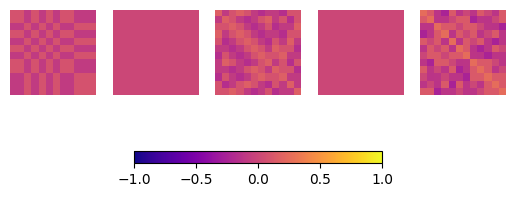

In [ ]:
vis.plot_matrices(tet_vib_irrep_proj);
print(Td_irreps_reordered_labels)
print("Irrep projector ranks: ", [np.linalg.matrix_rank(p) for p in tet_vib_irrep_proj])

1. Extract the vibration representation over the subgroup elements
2. Project the vibration representation under $C_{2v}$ to $E^{(T_d)}$ subspace
3. Find the change of basis between this new representation and $A_1^{(C_{2v})}$

In [ ]:
Td_vib_rep = vib_modes.vibration_representation(tet, Td_vec)
C2v_vib_rep = Td_vib_rep[sub_reordered_elements]

# Project C2v_vib_rep onto E irrep
C2v_vib_E_rep = np.einsum('ij,hjk,kl->hil', tet_vib_irrep_proj[2], C2v_vib_rep, tet_vib_irrep_proj[2].T)

# Project C2v_vib_rep onto T2 irrep
C2v_vib_T2_rep = np.einsum('ij,hjk,kl->hil', tet_vib_irrep_proj[4], C2v_vib_rep, tet_vib_irrep_proj[4].T)

# Find change of basis between (C2v vib rep projected onto Td E) and (C2v A1)
Td_E_to_C2v_A1_vib = linalg.infer_change_of_basis(C2v_vib_E_rep, C2v_irreps_reordered[0])

# Find change of basis between (C2v vib rep projected onto Td T2) and (C2v A1)
Td_T2_to_C2v_A1_vib = linalg.infer_change_of_basis(C2v_vib_T2_rep, C2v_irreps_reordered[0])

## And now we plot! These modes only breaks symmetry of $T_d$ not in (this particular copy of) $C_{2v}$.

If we chose a different represenation of the 3 possible $C_{2v}$ subgroup representations, we would see the same vibrational mode, just rotated.

Note, because we have "modded-out" the trivial $A_1^{(T_d)} \rightarrow A_1^{(C_{2v})}$ mode, these modes preserves volume, i.e. it contains no trivial scaling.

In [ ]:
vib_modes.plot_vibrational_mode(tet, Td_E_to_C2v_A1_vib.reshape(4, 3))

In [ ]:
vib_modes.plot_vibrational_mode(tet, Td_T2_to_C2v_A1_vib.reshape(4, 3))